# Proyecto 1 - Etapa 2: Rentrenamiento de modelos
Integrantes


*   Anderson Arevalo Mendoza, 202014997
*   Juan José Hurtado Cantin, 202224472
*   Nicolas Perez Ramos, 202221292

Librerias

In [2]:
import pandas as pd
# Manejo de gráficas
!pip install scikit-plot
# librería Natural Language Toolkit, usada para trabajar con textos
import nltk
# Punkt permite separar un texto en frases.
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Instalación de librerias

import numpy as np

!pip install pandas-profiling
!pip install contractions
!pip install ydata-profiling
!pip install num2words

from num2words import num2words
from ydata_profiling import ProfileReport
import re, string, unicodedata
import contractions
import inflect
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

import matplotlib.pyplot as plt
import copy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.4.2 which is incompatible.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


  Using cached joblib-1.1.1-py2.py3-none-any.whl.metadata (5.2 kB)
  Using cached visions-0.7.4-py3-none-any.whl.metadata (5.9 kB)
Using cached visions-0.7.4-py3-none-any.whl (102 kB)
Using cached joblib-1.1.1-py2.py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.4.2
    Uninstalling joblib-1.4.2:
      Successfully uninstalled joblib-1.4.2
  Attempting uninstall: visions
    Found existing installation: visions 0.8.1
    Uninstalling visions-0.8.1:
      Successfully uninstalled visions-0.8.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.16.1 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.
scikit-learn 1.6.1 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.


  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


Lectura de los datos



In [6]:
FilePath='./train.csv'
data=pd.read_csv(FilePath, sep=',')
X_data = data['Titulo'].astype(str) + " " + data['Descripcion'].astype(str)
y_data = data['Label']  # Etiqueta: 1 (Falso), 0 (Verdadero)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

spanish_stopwords = stopwords.words('spanish')

vectorizer = TfidfVectorizer(max_features=5000, stop_words=spanish_stopwords)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#MODELO ORIGINAL



📈 Métricas de Evaluación Random Forest Classifier:
Exactitud (Accuracy): 0.9337
Precisión (Precision): 0.9190
Sensibilidad (Recall): 0.9766
F1-Score: 0.9469

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2114
           1       0.92      0.98      0.95      3243

    accuracy                           0.93      5357
   macro avg       0.94      0.92      0.93      5357
weighted avg       0.94      0.93      0.93      5357



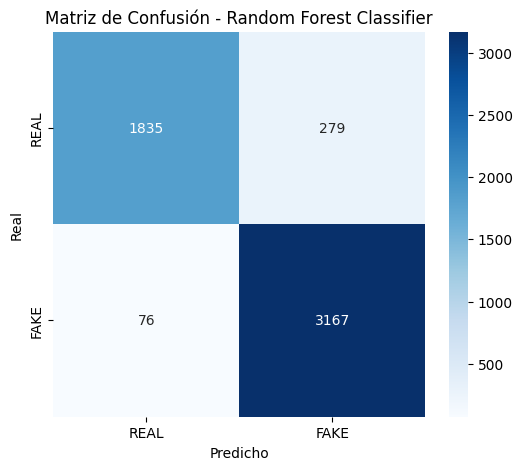

In [7]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=50, max_depth=2500, random_state=42)

clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\n📈 Métricas de Evaluación Random Forest Classifier:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest Classifier')
plt.show()

# Datos de Reentrenamiento

In [14]:
RetrainPath = './retrainData.csv'
retrain_data = pd.read_csv(RetrainPath, sep=',')


X_Retrain = retrain_data['Titulo'].astype(str) + " " + retrain_data['Descripcion'].astype(str)
y_Retrain = retrain_data['Label']  # Etiqueta: 1 (Falso), 0 (Verdadero)

X1_train, X1_test, y1_train, y1_test = train_test_split(X_Retrain, y_Retrain, test_size=0.2, random_state=42)

spanish_stopwords = stopwords.words('spanish')

vectorizer = TfidfVectorizer(max_features=5000, stop_words=spanish_stopwords)
X1_train_tfidf = vectorizer.fit_transform(X1_train)
X1_test_tfidf = vectorizer.transform(X1_test)

# Rentrena modelo- propuesta Anderson Arevalo: Reentrenamiento Completo (Batch Learning)


📈 Métricas de Evaluación Random Forest Classifier:
Exactitud (Accuracy): 0.9090
Precisión (Precision): 0.8936
Sensibilidad (Recall): 0.9626
F1-Score: 0.9268

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       574
           1       0.89      0.96      0.93       855

    accuracy                           0.91      1429
   macro avg       0.92      0.90      0.90      1429
weighted avg       0.91      0.91      0.91      1429



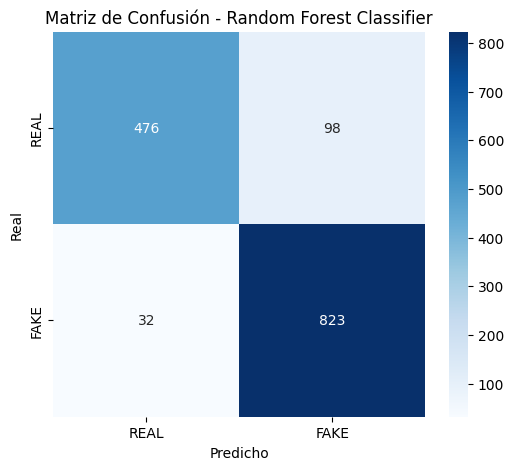

In [15]:
clfAAM = copy.deepcopy(clf)
clfAAM.fit(X1_train_tfidf, y1_train)

y1_pred = clfAAM.predict(X1_test_tfidf)
accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, pos_label=1)
recall = recall_score(y1_test, y1_pred, pos_label=1)
f1 = f1_score(y1_test, y1_pred, pos_label=1)

print("\n📈 Métricas de Evaluación Random Forest Classifier:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n📋 Reporte de Clasificación:")
print(classification_report(y1_test, y1_pred))

conf_matrix = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest Classifier')
plt.show()

# Rentrena modelo- propuesta

# Rentrena modelo- propuesta